In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
DAN = pd.read_csv("D:/M2_INOHA/DATA_SCIENCE/DATA-SCIENCE_M2_INOHA/INOHA-DataScience-M2/donnees_mpox_RDC_3000.csv")
DAN

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


In [ ]:
print("Aperçu des données épidémiologiques :")
print(DAN.head(10))

Aperçu des données épidémiologiques :
          ID  Semaine       Province  Pluviometrie_mm  Temperature_C   NDVI  \
0  OBS_00001        1        Mongala              206           24.4  0.480   
1  OBS_00002        2       Kinshasa               56           23.7  0.474   
2  OBS_00003        3       Kinshasa               59           25.2  0.333   
3  OBS_00004        4     Mai-Ndombe              396           24.1  0.354   
4  OBS_00005        5          Kasaï              127           19.8  0.303   
5  OBS_00006        6        Tshuapa              400           20.6  0.721   
6  OBS_00007        7  Kongo Central              181           26.6  0.779   
7  OBS_00008        8         Kwango              356           22.9  0.607   
8  OBS_00009        9         Tshopo              252           30.3  0.527   
9  OBS_00010       10          Kwilu               27           22.1  0.608   

   Humidite_pct  Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
0          

In [ ]:
print("\nStatistiques descriptives :")
print(DAN.describe())


Statistiques descriptives :
           Semaine  Pluviometrie_mm  Temperature_C         NDVI  Humidite_pct  \
count  3000.000000      3000.000000    3000.000000  3000.000000   3000.000000   
mean   1500.500000       157.779667      24.980367     0.451182     71.571667   
std     866.169729       101.958774       3.832510     0.157799     11.625285   
min       1.000000         2.000000      18.000000     0.103000     40.000000   
25%     750.750000        77.000000      22.300000     0.331000     64.000000   
50%    1500.500000       136.000000      24.900000     0.452000     71.500000   
75%    2250.250000       221.000000      27.600000     0.576000     80.000000   
max    3000.000000       400.000000      34.000000     0.795000     95.000000   

       Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
count         3000.000000               3000.000000     3000.000000   
mean           119.100333                 31.843967      286.143333   
std             95.218460   

# 2. Analyse Exploratoire des Données (EDA) Approfondie

## 2.1. Statistiques Descriptives et Distribution

In [ ]:
colonnes = ['Cas_Suspects', 'Cas_Confirmes']

for col in colonnes:
    if col in DAN.columns:
        print(f"{col} : OK")
    else:
        print(f"{col} : colonne absente")

Cas_Suspects : colonne absente
Cas_Confirmes : OK


In [ ]:
for col in DAN.columns:
    if "cas" in col.lower():
        print(col)

Cas_Confirmes


In [ ]:
print(DAN.columns.tolist())

['ID', 'Semaine', 'Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque', 'Taux_Positivite_pct']


In [ ]:
print("Statistiques descriptives :")
print(DAN[['Cas_Confirmes']].describe())

Statistiques descriptives :
       Cas_Confirmes
count    3000.000000
mean       79.603333
std        70.119799
min         0.000000
25%        29.000000
50%        57.000000
75%       109.000000
max       479.000000


In [ ]:
variables = [
    'Cas_Confirmes',
    'Tests_Realises',
    'Taux_Positivite_pct',
    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Population_Risque'
]

print(DAN[variables].describe())

       Cas_Confirmes  Tests_Realises  Taux_Positivite_pct  Pluviometrie_mm  \
count    3000.000000     3000.000000          3000.000000      3000.000000   
mean       79.603333      286.143333            27.041943       157.779667   
std        70.119799       88.256194            20.156959       101.958774   
min         0.000000       90.000000             0.000000         2.000000   
25%        29.000000      220.000000            11.430000        77.000000   
50%        57.000000      280.000000            21.455000       136.000000   
75%       109.000000      340.000000            38.070000       221.000000   
max       479.000000      800.000000            95.000000       400.000000   

       Temperature_C         NDVI  Humidite_pct  Population_Risque  
count    3000.000000  3000.000000   3000.000000        3000.000000  
mean       24.980367     0.451182     71.571667        5471.297667  
std         3.832510     0.157799     11.625285        2636.188129  
min        18.000000 

In [ ]:
print("Statistiques descriptives")
print(DAN.describe())

Statistiques descriptives
           Semaine  Pluviometrie_mm  Temperature_C         NDVI  Humidite_pct  \
count  3000.000000      3000.000000    3000.000000  3000.000000   3000.000000   
mean   1500.500000       157.779667      24.980367     0.451182     71.571667   
std     866.169729       101.958774       3.832510     0.157799     11.625285   
min       1.000000         2.000000      18.000000     0.103000     40.000000   
25%     750.750000        77.000000      22.300000     0.331000     64.000000   
50%    1500.500000       136.000000      24.900000     0.452000     71.500000   
75%    2250.250000       221.000000      27.600000     0.576000     80.000000   
max    3000.000000       400.000000      34.000000     0.795000     95.000000   

       Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
count         3000.000000               3000.000000     3000.000000   
mean           119.100333                 31.843967      286.143333   
std             95.218460      

In [ ]:
variables = [
    'Cas_Confirmes',
    'Tests_Realises',
    'Taux_Positivite_pct',
    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Densite_Population',
    'Couverture_Vaccinale_pct',
    'Distance_Centre_Sante_km',
    'Population_Risque'
]

print(DAN[variables].describe())

       Cas_Confirmes  Tests_Realises  Taux_Positivite_pct  Pluviometrie_mm  \
count    3000.000000     3000.000000          3000.000000      3000.000000   
mean       79.603333      286.143333            27.041943       157.779667   
std        70.119799       88.256194            20.156959       101.958774   
min         0.000000       90.000000             0.000000         2.000000   
25%        29.000000      220.000000            11.430000        77.000000   
50%        57.000000      280.000000            21.455000       136.000000   
75%       109.000000      340.000000            38.070000       221.000000   
max       479.000000      800.000000            95.000000       400.000000   

       Temperature_C         NDVI  Humidite_pct  Densite_Population  \
count    3000.000000  3000.000000   3000.000000         3000.000000   
mean       24.980367     0.451182     71.571667          119.100333   
std         3.832510     0.157799     11.625285           95.218460   
min        18

# 2. ANALYSE DES CORRÉLATIONS

### Objectif :
#### Identifier les facteurs environnementaux associés aux cas confirmés.

## 2.1 Matrice de corrélation

In [ ]:
corr = DAN.select_dtypes(
    include=np.number
).corr()

corr

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
Semaine,1.000000,0.021729,-0.003056,-0.008289,-0.004408,-0.024729,-0.006269,0.008703,-0.019993,0.011058,-0.023608,0.007926,0.038807,0.009897
Pluviometrie_mm,0.021729,1.000000,0.026601,-0.025333,-0.017752,0.014991,-0.012357,0.001739,0.034043,-0.023265,0.010007,0.625170,0.013184,0.735529
Temperature_C,-0.003056,0.026601,1.000000,0.010839,0.013354,-0.015716,0.011588,-0.030491,0.007746,0.007841,0.005675,0.131251,0.025079,0.159576
NDVI,-0.008289,-0.025333,0.010839,1.000000,-0.014116,-0.013468,0.031270,-0.041643,-0.026057,-0.011831,0.025868,0.091674,0.013683,0.126989
Humidite_pct,-0.004408,-0.017752,0.013354,-0.014116,1.000000,-0.029717,0.021939,0.007457,0.001039,-0.016566,0.005139,0.042544,0.001847,0.057886
Densite_Population,-0.024729,0.014991,-0.015716,-0.013468,-0.029717,1.000000,0.033371,-0.017050,0.029964,0.003835,0.013249,0.181571,0.023336,0.218059
Couverture_Vaccinale_pct,-0.006269,-0.012357,0.011588,0.031270,0.021939,0.033371,1.000000,-0.021319,-0.007123,-0.016166,-0.025612,-0.350440,0.019925,-0.401540
Tests_Realises,0.008703,0.001739,-0.030491,-0.041643,0.007457,-0.017050,-0.021319,1.000000,-0.020806,-0.030859,0.011500,0.462248,0.008702,0.125094
Distance_Centre_Sante_km,-0.019993,0.034043,0.007746,-0.026057,0.001039,0.029964,-0.007123,-0.020806,1.000000,0.007642,-0.008218,-0.153797,-0.031513,-0.180879
Reservoirs_Animaux,0.011058,-0.023265,0.007841,-0.011831,-0.016566,0.003835,-0.016166,-0.030859,0.007642,1.000000,-0.005084,-0.040024,0.001673,-0.025492


## 2.2 Carte thermique

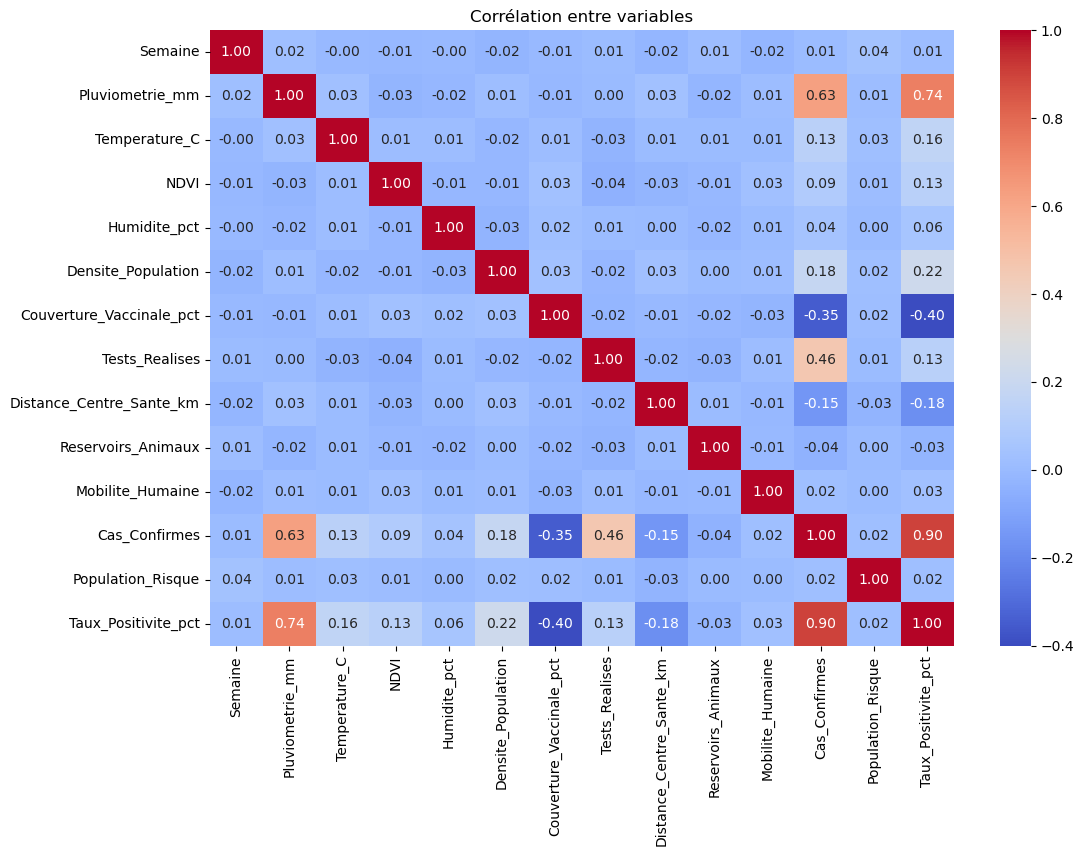

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Corrélation entre variables")
plt.show()

## 2.3 Corrélation avec les cas confirmés

In [ ]:
corr_cas = corr["Cas_Confirmes"].sort_values(
    ascending=False
)

print(corr_cas)

Cas_Confirmes               1.000000
Taux_Positivite_pct         0.899874
Pluviometrie_mm             0.625170
Tests_Realises              0.462248
Densite_Population          0.181571
Temperature_C               0.131251
NDVI                        0.091674
Humidite_pct                0.042544
Mobilite_Humaine            0.024719
Population_Risque           0.022979
Semaine                     0.007926
Reservoirs_Animaux         -0.040024
Distance_Centre_Sante_km   -0.153797
Couverture_Vaccinale_pct   -0.350440
Name: Cas_Confirmes, dtype: float64


## 3. VISUALISATIONS ÉPIDÉMIOLOGIQUES

### 3.1 Distribution des cas confirmés

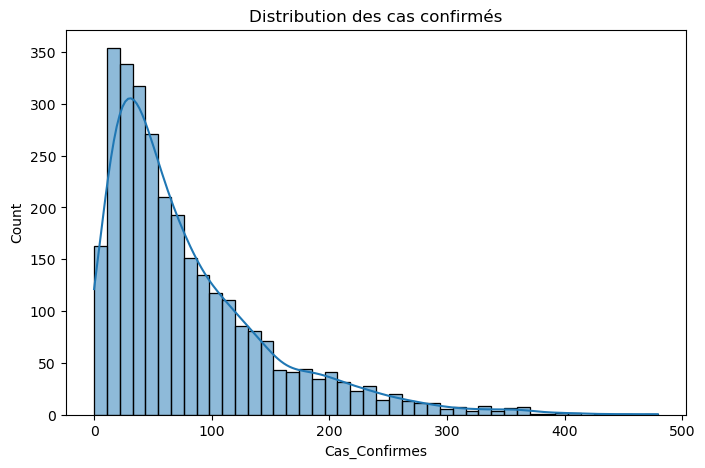

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    DAN["Cas_Confirmes"],
    kde=True
)

plt.title(
    "Distribution des cas confirmés"
)

plt.show()

### 3.2 Cas confirmés par province

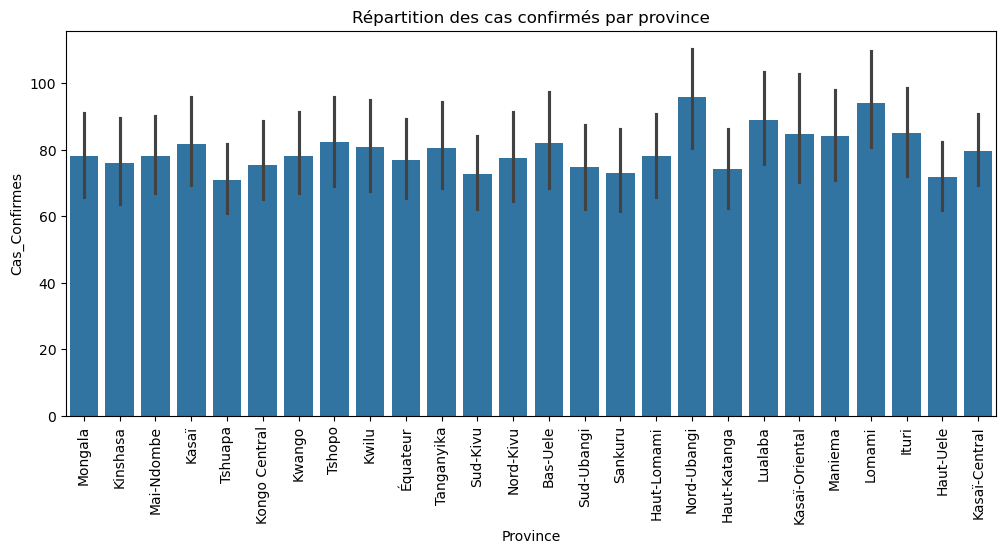

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=DAN,
    x="Province",
    y="Cas_Confirmes"
)

plt.xticks(
    rotation=90
)

plt.title(
    "Répartition des cas confirmés par province"
)

plt.show()

### 3.3 Relation NDVI - Cas confirmés

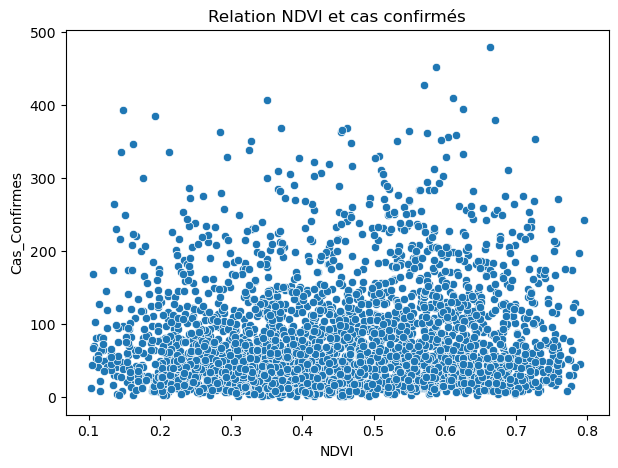

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=DAN,
    x="NDVI",
    y="Cas_Confirmes"
)

plt.title(
    "Relation NDVI et cas confirmés"
)

plt.show()

### 3.4 Relation pluie - cas

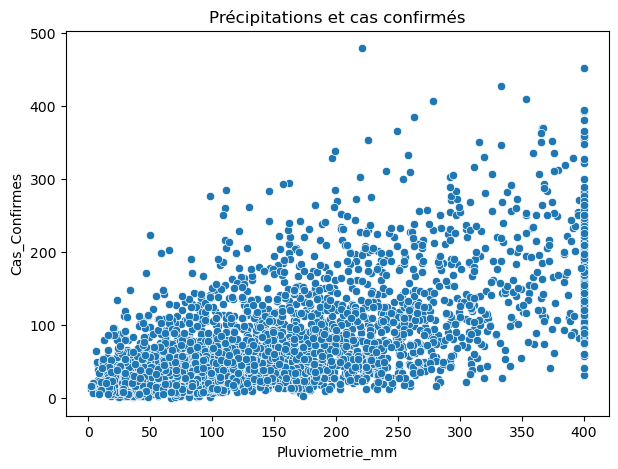

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=DAN,
    x="Pluviometrie_mm",
    y="Cas_Confirmes"
)

plt.title(
    "Précipitations et cas confirmés"
)

plt.show()

## 4. MODÉLISATION PAR RÉGRESSION
### Objectif :

### Prédire le nombre de cas confirmés selon les facteurs écologiques.

In [ ]:
X = DAN[
[
'Pluviometrie_mm',
'Temperature_C',
'NDVI',
'Humidite_pct',
'Densite_Population',
'Couverture_Vaccinale_pct',
'Tests_Realises',
'Distance_Centre_Sante_km',
'Reservoirs_Animaux',
'Mobilite_Humaine'
]
]


y = DAN["Cas_Confirmes"]

### 4.2 Division apprentissage/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 4.3 Régression linéaire

In [ ]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

# Prédiction
y_pred = model.predict(X_test)

### 4.4 Évaluation

In [ ]:
# Importation des métriques d'évaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("Importation réussie")

Importation réussie


In [ ]:
print(
"MSE :",
mean_squared_error(y_test,y_pred)
)

print(
"RMSE :",
np.sqrt(mean_squared_error(y_test,y_pred))
)

print(
"MAE :",
mean_absolute_error(y_test,y_pred)
)

print(
"R² :",
r2_score(y_test,y_pred)
)

MSE : 933.2965647012993
RMSE : 30.54990285911396
MAE : 22.150635752135198
R² : 0.825756695637048


### INTERPRETATION
#### Le modèle de régression linéaire multiple présente une bonne capacité explicative avec un coefficient de détermination R² de 0,826. Ainsi, les variables environnementales, démographiques et sanitaires considérées expliquent environ 82,6 % de la variabilité des cas confirmés. L'erreur moyenne de prédiction est estimée à 22 cas selon le MAE et à environ 31 cas selon le RMSE, indiquant une performance satisfaisante du modèle.

## 5. MACHINE LEARNING
### 5.1 Random Forest Regression

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

#### Créer le modèle

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

#### Entraîner le modèle

In [ ]:
rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, random_state=42)

#### Faire les prédictions

In [ ]:
pred_rf = rf.predict(
    X_test
)

#### Évaluer Random Forest

In [ ]:
## EVALUTION
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


print(
    "MSE Random Forest :",
    mean_squared_error(y_test, pred_rf)
)

print(
    "RMSE Random Forest :",
    np.sqrt(mean_squared_error(y_test, pred_rf))
)

print(
    "MAE Random Forest :",
    mean_absolute_error(y_test, pred_rf)
)

print(
    "R² Random Forest :",
    r2_score(y_test, pred_rf)
)

MSE Random Forest : 743.4752239999999
RMSE Random Forest : 27.266742086285262
MAE Random Forest : 18.67815
R² Random Forest : 0.8611956963720242


In [ ]:
print(
"R² Random Forest :",
r2_score(
    y_test,
    pred_rf
)
)

R² Random Forest : 0.8611956963720242


### Random Forest améliore la capacité prédictive de 3,55 points de pourcentage par rapport à la régression linéaire.  
#### Random Forest peut capturer : des relations non linéaires ; des interactions entre variables ; des effets complexes.
#### Exemple : L'effet de la pluviométrie peut dépendre : du niveau de végétation (NDVI) ; de la densité humaine ; de la présence de réservoirs animaux.

## 5.2 Importance des variables

In [ ]:
importance = pd.DataFrame(
{
"Variable":X.columns,
"Importance":rf.feature_importances_
}
)


importance.sort_values(
"Importance",
ascending=False
)

,Variable,Importance
0,Pluviometrie_mm,0.420965
6,Tests_Realises,0.265241
5,Couverture_Vaccinale_pct,0.149780
4,Densite_Population,0.044195
2,NDVI,0.034956
7,Distance_Centre_Sante_km,0.031247
1,Temperature_C,0.029121
3,Humidite_pct,0.014489
9,Mobilite_Humaine,0.007963
8,Reservoirs_Animaux,0.002043


##### Graphique :

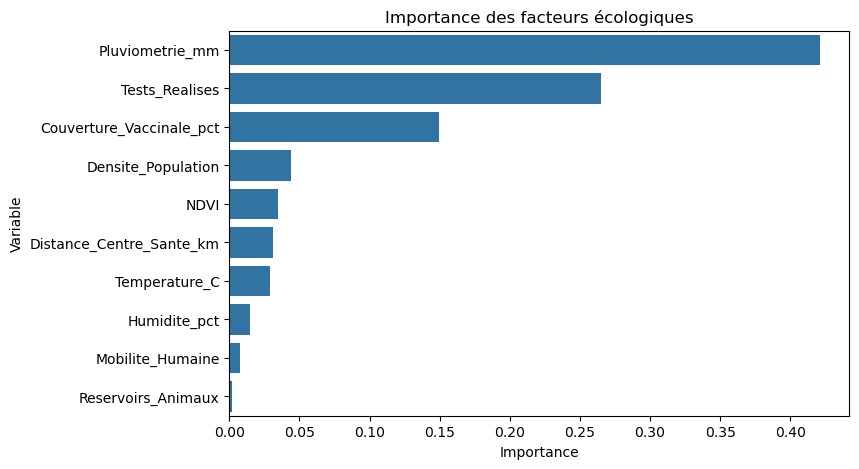

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
data=importance.sort_values(
"Importance",
ascending=False
),
x="Importance",
y="Variable"
)

plt.title(
"Importance des facteurs écologiques"
)

plt.show()

####  L'analyse de l'importance des variables issues du modèle XGBoost révèle une prédominance des facteurs environnementaux et sanitaires dans la prédiction des cas confirmés. La pluviométrie constitue le déterminant prédictif principal avec une contribution de 42,1 %, suivie du nombre de tests réalisés (26,5 %) et de la couverture vaccinale (15 %). Ces résultats suggèrent que la dynamique observée des cas résulte à la fois des conditions écologiques favorables et de l'intensité de la surveillance sanitaire. Les variables liées à la structure spatiale, telles que la densité de population, le NDVI et la distance aux centres de santé, présentent une contribution secondaire. La faible importance attribuée aux réservoirs animaux souligne davantage une limitation liée à la disponibilité et à la résolution des données qu'une absence d'effet écologique.

## 5.3 XGBoost

In [ ]:
pip install xgboost

In [ ]:
import xgboost as xgb

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)


xgb_model.fit(
    X_train,
    y_train
)


pred_xgb = xgb_model.predict(
    X_test
)

##### Performance :

In [ ]:
print(
"R² XGBoost :",
r2_score(
    y_test,
    pred_xgb
)
)

R² XGBoost : 0.9008572101593018


#### INTERPRETATION : XGBoost présente la meilleure performance prédictive parmi les trois approches testées, avec un R² de 0,901. Cela signifie qu'environ 90 % de la variabilité des cas confirmés est expliquée par les variables environnementales, démographiques et sanitaires considérées.


## 6. Comparaison des modèles

In [ ]:
resultats = pd.DataFrame({

"Modele":[
"Régression linéaire",
"Random Forest",
"XGBoost"
],

"R2":[

r2_score(y_test,y_pred),

r2_score(y_test,pred_rf),

r2_score(y_test,pred_xgb)

]

})


resultats

,Modele,R2
0,Régression linéaire,0.825757
1,Random Forest,0.861196
2,XGBoost,0.900857


#### Les performances des trois modèles montrent une amélioration progressive de la capacité prédictive avec l'utilisation des algorithmes d'apprentissage automatique. La régression linéaire multiple présente un coefficient de détermination de 0,826, indiquant une bonne capacité explicative des facteurs environnementaux et épidémiologiques. Le modèle Random Forest améliore cette performance avec un R² de 0,861. Le modèle XGBoost obtient la meilleure performance avec un R² de 0,901, traduisant une capacité supérieure à capturer les relations non linéaires et les interactions complexes entre les déterminants écologiques et la dynamique des cas confirmés.